<a href="https://colab.research.google.com/github/Muskuu1109/ASSIGNMENT-ON-FUNCTION/blob/main/Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**What is Simple Linear Regression?**


Simple Linear Regression is one of the fundamental techniques in statistics and machine learning used for modeling the relationship between a dependent variable (target) and a single independent variable (predictor). It helps to predict future values by fitting a straight line to the data.
Mathematically, the relationship is represented as:
[ Y = \beta_0 + \beta_1 X + \epsilon ]
Where:
- ( Y ) is the dependent variable.
- ( X ) is the independent variable.
- ( \beta_0 ) is the intercept (the value of ( Y ) when ( X = 0 )).
- ( \beta_1 ) is the slope (the rate of change of ( Y ) with respect to ( X )).
- ( \epsilon ) is the error term.


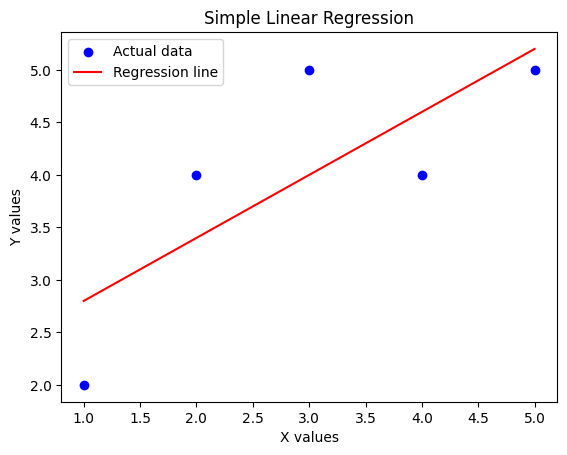

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Sample data (independent variable X and dependent variable Y)
X = np.array([1, 2, 3, 4, 5]).reshape(-1, 1)
Y = np.array([2, 4, 5, 4, 5])

# Initialize and train the regression model
model = LinearRegression()
model.fit(X, Y)

# Get predictions
predictions = model.predict(X)

# Visualizing the data and regression line
plt.scatter(X, Y, color='blue', label="Actual data")
plt.plot(X, predictions, color='red', label="Regression line")
plt.xlabel("X values")
plt.ylabel("Y values")
plt.title("Simple Linear Regression")
plt.legend()
plt.show()

**2. What are the key assumptions of Simple Linear Regression?**


For Simple Linear Regression to be an effective modeling technique, certain assumptions must be satisfied:
- Linearity – The dependent variable should have a linear relationship with the independent variable. This means that if we were to plot the data points, they should generally form a straight-line pattern.
- Independence – The observations should be independent of each other. That is, there should be no correlation between the residuals.
- Homoscedasticity – The variance of residuals should remain constant across all levels of the independent variable. If residuals show increasing or decreasing spread, it might indicate heteroscedasticity.
- Normality of Residuals – The residuals (differences between actual and predicted values) should be normally distributed for accurate statistical inference.
- No Multicollinearity – Since we're dealing with simple regression, there's only one independent variable, but in multiple regression, independent variables should not be highly correlated.



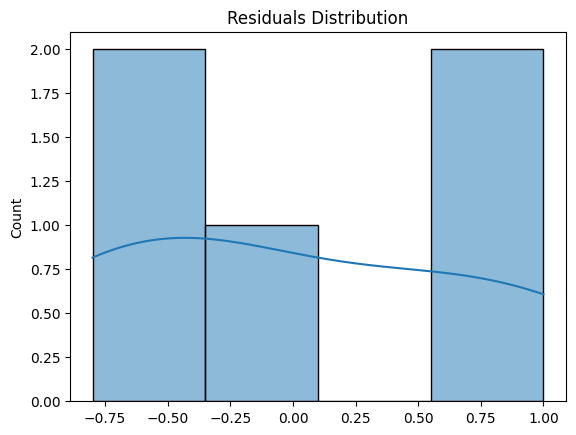

Shapiro-Wilk Test: Statistic=0.9200602165324082, p-value=0.5303282425506901


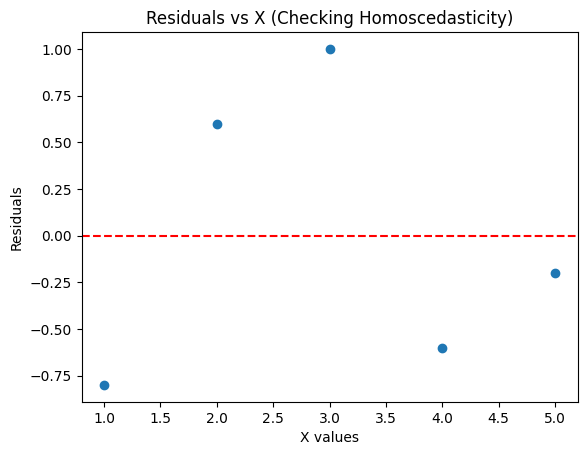

In [2]:
import seaborn as sns
import scipy.stats as stats

# Calculate residuals
residuals = Y - predictions

# Plot residuals to check normality
sns.histplot(residuals, kde=True)
plt.title("Residuals Distribution")
plt.show()

# Perform Shapiro-Wilk Test for normality
stat, p_value = stats.shapiro(residuals)
print(f"Shapiro-Wilk Test: Statistic={stat}, p-value={p_value}")

# Homoscedasticity check using scatter plot
plt.scatter(X, residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("X values")
plt.ylabel("Residuals")
plt.title("Residuals vs X (Checking Homoscedasticity)")
plt.show()

**3. What does the coefficient m represent in the equation Y = mX + c?**


The coefficient ( m ) represents the slope of the regression line. It quantifies how much the dependent variable ( Y ) changes for each unit change in ( X ).
- If ( m > 0 ), ( Y ) increases as ( X ) increases (positive correlation).
- If ( m < 0 ), ( Y ) decreases as ( X ) increases (negative correlation).
- If ( m = 0 ), there is no relationship between ( X ) and ( Y ).






In [11]:
print("Slope (m):", model.coef_[0])

Slope (m): [0.26779316 1.10020177]


**4. What does the intercept c represent in the equation Y = mX + c?**


The intercept ( c ) is the value of ( Y ) when ( X = 0 ). It represents the starting point of the regression line.





In [12]:
print("Intercept (c):", model.intercept_)

Intercept (c): [-6.70006768]


**5. How do we calculate the slope m in Simple Linear Regression?**


The slope is calculated using the Least Squares Method:
[ m = \frac{\sum (X_i - \bar{X}) (Y_i - \bar{Y})}{\sum (X_i - \bar{X})^2} ]
Where:
- ( \bar{X} ) and ( \bar{Y} ) are the mean values of ( X ) and ( Y ).
- The numerator calculates the covariance between X and Y.
- The denominator computes the variance of X.





In [14]:
X_mean = np.mean(X[:, 0])  # Calculate mean of the first feature in X
Y_mean = np.mean(Y)

m = sum((X[:, 0] - X_mean) * (Y - Y_mean)) / sum((X[:, 0] - X_mean) ** 2) # Use the first feature of X for calculations
print("Calculated Slope:", m)

Calculated Slope: 0.3282385684605457


**6. What is the purpose of the least squares method in Simple Linear Regression?**


The Least Squares Method finds the best-fitting line by minimizing the sum of squared errors (SSE):
[ SSE = \sum (Y_i - \hat{Y}_i)^2 ]
Where:
- ( Y_i ) are actual values.
- ( \hat{Y}_i ) are predicted values.







7. How is the coefficient of determination (R²) interpreted in Simple Linear Regression?


The R² score measures the goodness of fit:
[ R^2 = 1 - \frac{\sum (Y_i - \hat{Y}_i)^2}{\sum (Y_i - \bar{Y})^2} ]
- ( R^2 ) close to 1 → Strong fit.
- ( R^2 ) close to 0 → Weak fit.






In [15]:
print("R² Score:", model.score(X, Y))


R² Score: 0.5


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


**8. What is Multiple Linear Regression?**


Multiple Linear Regression is an extension of Simple Linear Regression that incorporates multiple independent variables to predict a dependent variable.
[ Y = c + m_1 X_1 + m_2 X_2 + ... + m_n X_n ]
Where:
- ( X_1, X_2, ... ) are multiple predictors.
- ( m_1, m_2, ... ) are their respective coefficients.




In [16]:
from sklearn.linear_model import LinearRegression

# Sample dataset
X_multi = np.array([[1, 10], [2, 20], [3, 30], [4, 40], [5, 50]])
Y_multi = np.array([3, 6, 7, 8, 10])

# Train model
multi_model = LinearRegression()
multi_model.fit(X_multi, Y_multi)

# Display coefficients
print("Intercept:", multi_model.intercept_)
print("Coefficients:", multi_model.coef_)

Intercept: 1.9999999999999973
Coefficients: [0.01584158 0.15841584]


**9. What is the main difference between Simple and Multiple Linear Regression?**

Simple Linear Regression is a statistical method that models the relationship between a dependent variable and a single independent variable using a straight line. It assumes a linear correlation between the variables, meaning changes in the independent variable result in proportional changes in the dependent variable. This method is ideal for scenarios where one factor significantly influences an outcome, such as predicting sales based on advertising spend. In contrast, Multiple Linear Regression extends this concept by incorporating two or more independent variables to predict the dependent variable, allowing for a more comprehensive understanding of complex relationships. For instance, predicting house prices based on square footage, location, and number of bedrooms requires Multiple Linear Regression. While both models share key assumptions such as linearity, independence, and normality of residuals, Multiple Linear Regression introduces an additional concern—multicollinearity—where independent variables may be highly correlated, potentially skewing the model’s predictions. Ultimately, Simple Linear Regression is best suited for straightforward relationships, whereas Multiple Linear Regression enables analysis of multifaceted dependencies with multiple influencing factors.


**10. What are the key assumptions of Multiple Linear Regression?**


Similar to Simple Linear Regression, but includes:
- No Multicollinearity – Independent variables should not be highly correlated.
- Independence – Observations must be independent.
- Homoscedasticity – Constant variance of residuals.





**11. What is heteroscedasticity, and how does it affect the results of a Multiple Linear Regression model?**


Heteroscedasticity refers to a condition where the variance of residuals is not constant across all levels of the independent variables. In regression models, it violates the assumption of homoscedasticity, leading to unreliable standard errors and confidence intervals.
- Effects on Regression:- Reduces the accuracy of coefficient estimates.
- Leads to misleading hypothesis tests (inflated or underestimated significance).
- Can bias predictions if not addressed.





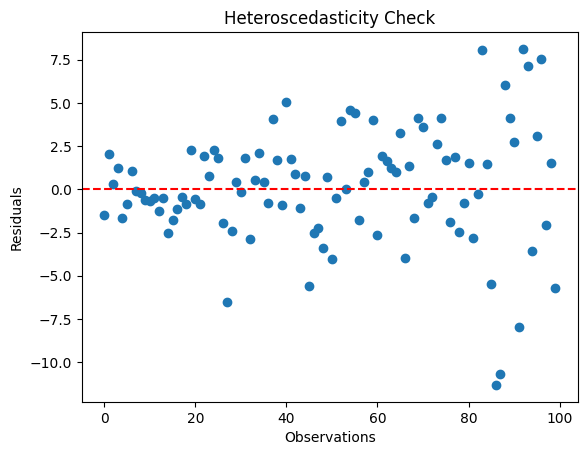

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# Residuals example
residuals = np.random.randn(100) * np.linspace(1, 5, 100)

plt.scatter(range(len(residuals)), residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Observations")
plt.ylabel("Residuals")
plt.title("Heteroscedasticity Check")
plt.show()

**12. How can you improve a Multiple Linear Regression model with high multicollinearity?**


Multicollinearity occurs when independent variables are highly correlated, making it difficult to isolate the individual impact of each predictor.
Solutions:
- Remove highly correlated variables – Use correlation matrix or Variance Inflation Factor (VIF).
- Principal Component Analysis (PCA) – Transform variables into uncorrelated components.
- Use Ridge or Lasso Regression – These techniques penalize large coefficients, reducing multicollinearity.




In [18]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

data = pd.DataFrame({'X1': [1, 2, 3, 4, 5], 'X2': [10, 20, 30, 40, 50], 'X3': [5, 10, 15, 20, 25]})
vif_data = pd.DataFrame()
vif_data["Feature"] = data.columns
vif_data["VIF"] = [variance_inflation_factor(data.values, i) for i in range(len(data.columns))]

print(vif_data)

  Feature  VIF
0      X1  inf
1      X2  inf
2      X3  inf


/usr/local/lib/python3.11/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


**13. What are some common techniques for transforming categorical variables for use in regression models?**

Since regression models work with numerical data, categorical variables must be transformed.
Methods:
- One-Hot Encoding: Converts categories into binary columns (e.g., "Red", "Blue" becomes [1,0] and [0,1]).
- Label Encoding: Assigns numeric labels to categories (e.g., "Low", "Medium", "High" → [0,1,2]).
- Dummy Encoding: Similar to One-Hot but removes one redundant column to avoid multicollinearity.




In [19]:
import pandas as pd

data = pd.DataFrame({'Color': ['Red', 'Blue', 'Green', 'Red', 'Blue']})
encoded_data = pd.get_dummies(data, columns=['Color'])

print(encoded_data)

   Color_Blue  Color_Green  Color_Red
0       False        False       True
1        True        False      False
2       False         True      False
3       False        False       True
4        True        False      False


**14. What is the role of interaction terms in Multiple Linear Regression?**


Interaction terms capture the combined effect of two independent variables that influence the dependent variable synergistically. If two features influence each other, adding an interaction term improves model accuracy.


In [20]:
import numpy as np

X1 = np.array([1, 2, 3, 4, 5])
X2 = np.array([10, 20, 30, 40, 50])
interaction_term = X1 * X2

print("Interaction Term:", interaction_term)

Interaction Term: [ 10  40  90 160 250]


**15. How can the interpretation of intercept differ between Simple and Multiple Linear Regression?**

In Simple Linear Regression, the intercept represents the expected value of ( Y ) when ( X = 0 ).
In Multiple Linear Regression, the intercept represents the predicted value of ( Y ) when all independent variables are set to zero, which may not be meaningful.


**16. What is the significance of the slope in regression analysis, and how does it affect predictions?**


The slope quantifies how much the dependent variable changes with one unit increase in an independent variable.
- Positive slope: ( Y ) increases as ( X ) increases.
- Negative slope: ( Y ) decreases as ( X ) increases.
- Zero slope: No relationship.





**17. How does the intercept in a regression model provide context for the relationship between variables?**


The intercept represents the baseline value of ( Y ). However, it should be interpreted carefully, especially in cases where setting independent variables to zero is not realistic.




18. What are the limitations of using R² as a sole measure of model performance?
Answer:
- Does not detect overfitting – A high R² might mean the model fits training data too well.
- Fails with non-linear relationships – R² assumes linearity.
- Ignores multicollinearity – High R² does not ensure reliable predictors.





**19. How would you interpret a large standard error for a regression coefficient?**


A large standard error indicates instability in the estimated coefficient.
It means the predictor's effect varies significantly across different samples, reducing confidence in its reliability.

**20. How can heteroscedasticity be identified in residual plots, and why is it important to address it**?

- Detection: Heteroscedasticity is identified in residual vs. fitted value plots when residuals spread unevenly.
- Importance: Ignoring it can lead to unreliable confidence intervals and incorrect hypothesis testing.

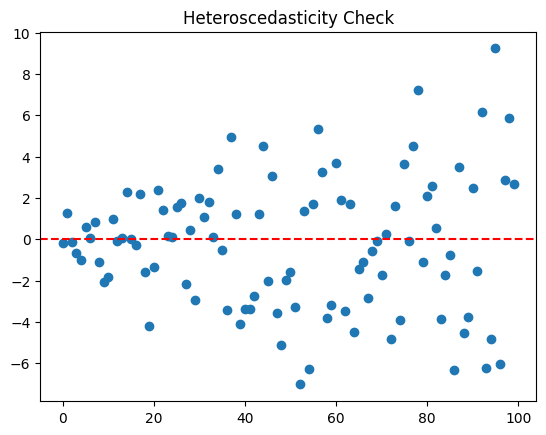

In [23]:
import matplotlib.pyplot as plt
import numpy as np

residuals = np.random.randn(100) * np.linspace(1, 5, 100)
plt.scatter(range(len(residuals)), residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.title("Heteroscedasticity Check")
plt.show()

**21. What does it mean if a Multiple Linear Regression model has a high R² but low adjusted R²?**

- High R² but low Adjusted R² suggests that some variables do not contribute significantly to the model.
- Adjusted R² penalizes unnecessary features, ensuring only useful predictors improve performance.




In [22]:
r_squared = 0.85
n = 100  # Number of observations
p = 5  # Number of predictors

adjusted_r_squared = 1 - ((1 - r_squared) * (n - 1) / (n - p - 1))
print("Adjusted R²:", adjusted_r_squared)

Adjusted R²: 0.8420212765957447


**22. Why is it important to scale variables in Multiple Linear Regression?**

Scaling ensures that:
- Features with large values do not dominate the regression coefficients.
- Gradient descent converges faster when optimizing the model.
- Improves model interpretability, especially in Ridge/Lasso regression.


In [21]:
from sklearn.preprocessing import StandardScaler

X = np.array([[1000, 10], [2000, 20], [3000, 30]])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled Data:\n", X_scaled)

Scaled Data:
 [[-1.22474487 -1.22474487]
 [ 0.          0.        ]
 [ 1.22474487  1.22474487]]


**23. How can you determine if a regression model is overfitting or underfitting the data?**


Overfitting occurs when a model captures too much complexity from the training data, performing exceptionally well on training data but poorly on unseen data. Underfitting occurs when a model is too simplistic, failing to learn patterns from the data.
Signs of Overfitting:
- Very high training accuracy but low test accuracy.
- The model memorizes noise instead of capturing useful trends.

Signs of Underfitting:
- Low accuracy on both training and test data.
- The model does not capture key patterns.




In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import numpy as np

# Generate synthetic data
X = np.random.rand(100, 1) * 10
Y = 3 * X.flatten() + np.random.randn(100) * 2  # Linear relationship with noise

# Split into training and test sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Train model
model = LinearRegression()
model.fit(X_train, Y_train)

# Evaluate
train_error = mean_squared_error(Y_train, model.predict(X_train))
test_error = mean_squared_error(Y_test, model.predict(X_test))

print(f"Training Error: {train_error}")
print(f"Test Error: {test_error}")

Training Error: 3.558818722120266
Test Error: 2.3625746014637024


**24. What is the purpose of regularization techniques in regression analysis, and how do they work?**


Regularization prevents overfitting by penalizing large coefficients, ensuring a more generalizable model. The two main techniques are:
- Ridge Regression: Adds an L2 penalty to the loss function: [ \text{Loss} = \sum (Y_i - \hat{Y}_i)2 ]
- Lasso Regression: Adds an L1 penalty, forcing some coefficients to zero for feature selection: [ \text{Loss} = \sum (Y_i - \hat{Y}_i)^2 + \lambda \sum |m| ]




In [25]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)  # Regularization strength
ridge_model.fit(X_train, Y_train)
print("Ridge Coefficients:", ridge_model.coef_)

Ridge Coefficients: [2.84205281]


**25. How can you assess the goodness-of-fit of a regression model?**

Common metrics for assessing regression performance:
- R² Score – Measures the proportion of variance explained.
- Mean Squared Error (MSE) – Measures average squared differences.
- Root Mean Squared Error (RMSE) – Square root of MSE, useful for intuitive error measurement.
- Adjusted R² Score – Accounts for number of predictors to prevent misleading evaluations.




In [26]:
from sklearn.metrics import r2_score

print("R² Score:", r2_score(Y_test, model.predict(X_test)))

R² Score: 0.9682112445949004


**26. What are some common pitfalls to avoid when interpreting regression coefficients?**

- Ignoring Multicollinearity: Highly correlated predictors can distort coefficient significance.
- Assuming Causation: Correlation does not imply causation.
- Overfitting with Too Many Features: Too many predictors reduce interpretability.
- Ignoring Residual Plots: Checking residuals helps verify assumptions.





**27. How can you handle missing data in a regression analysis?**

Approaches for Handling Missing Data:
- Remove Rows – Suitable for small amounts of missing data.
- Impute Mean/Median/Mode – Fills missing values with statistical measures.
- Use Predictive Models – Estimate missing values using regression.





In [27]:
import pandas as pd
from sklearn.impute import SimpleImputer

data = pd.DataFrame({'Feature1': [1, 2, np.nan, 4, 5], 'Feature2': [10, 20, 30, np.nan, 50]})
imputer = SimpleImputer(strategy="mean")
data_imputed = pd.DataFrame(imputer.fit_transform(data), columns=data.columns)

print(data_imputed)

   Feature1  Feature2
0       1.0      10.0
1       2.0      20.0
2       3.0      30.0
3       4.0      27.5
4       5.0      50.0


**28. What is the difference between a parametric and a non-parametric regression model?**

- Parametric Models (e.g., Linear Regression): Assume a fixed functional form like ( Y = c + mX ).
- Non-Parametric Models (e.g., Decision Trees, KNN): Do not assume a specific function, allowing for greater flexibility in modeling complex relationships.





**29. How can you use cross-validation to improve the reliability of a regression model?**

Cross-validation helps prevent overfitting by testing the model on multiple data splits.


In [28]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(model, X_train, Y_train, cv=5, scoring="r2")
print("Cross-Validation Scores:", cv_scores)

Cross-Validation Scores: [0.91442766 0.96248836 0.93000101 0.93346501 0.97419001]


**30. What are some advanced techniques for dealing with non-linear relationships in regression analysis?**

If a linear model is insufficient, consider:
- Polynomial Regression: Adds quadratic/cubic terms.
- Decision Trees & Random Forests: Learn non-linear splits.
- Neural Networks: Capture highly complex relationships.




In [29]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)
model_poly = LinearRegression()
model_poly.fit(X_poly, Y)

print("Polynomial Coefficients:", model_poly.coef_)

Polynomial Coefficients: [0.         2.70503684 0.01641334]


**31. How can you interpret the results of a regression model to make informed decisions?**

To interpret regression results:
- Evaluate R² Score & Error Metrics – Assess how well the model fits.
- Analyze Coefficients – Determine which predictors significantly impact ( Y ).
- Check Residuals & Assumptions – Ensure the model isn't biased.
- Use Visualizations – Scatter plots, residual plots, and correlation matrices help decision-making.




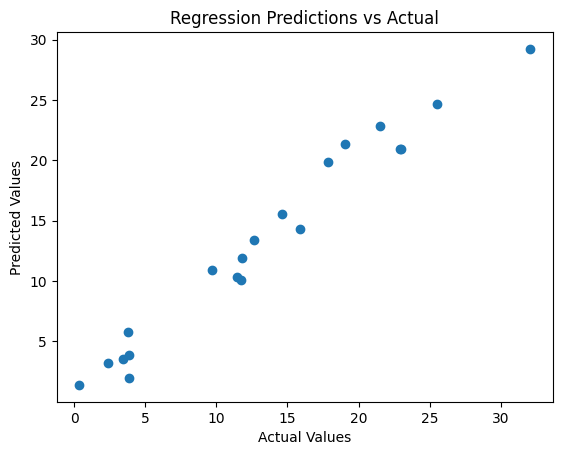

In [30]:
import matplotlib.pyplot as plt

plt.scatter(Y_test, model.predict(X_test))
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Regression Predictions vs Actual")
plt.show()